## **7° Module**: TT - Classification
* October 6°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 6 measured separability with global metrics. This module asks the question of OE-4 and OE-5: does any representation let a classifier tell benign from malignant lesions better? A classifier can exploit local structure that a global metric averages away, so the answer is not implied by Module 6.

**One classifier for all conditions.** The same multilayer perceptron (MLP) is trained on each of the five 12-dimensional representations of Module 5, with the same architecture, hyperparameters, training rule and seed. The only thing that changes between conditions is the representation, so a difference in performance can be attributed to it. Masses and calcifications are separate problems (D-005).

**No quantum computation in the training loop (D-014).** The quantum embeddings were computed once, with the ansatz parameters $\theta$ fixed by seed 42, and are read from disk. Training is a classical problem on a 12-column table, and takes seconds.

**Evaluation (D-018).**

- **5-fold cross-validation on the training split**, with the folds frozen in Module 4: grouped by patient, so that no patient has lesions on both sides of a split (H-027).
- **The official test split of the CBIS-DDSM** as the final evaluation. It is used once per model, after every choice has been fixed.

**Sensitivity analyses** declared in advance in the records, so that the main result can be read against them:

- the ansatz with **two layers** (reps = 2), which H-018 measured as 30 % more dispersed at $k=12$ on synthetic inputs;
- **8 qubits** instead of 12, with the embeddings of experiment X3 (D-035);
- five **initialization seeds** and four **alternative configurations**, one of them without early stopping, to measure how much of a difference between conditions is noise of the training procedure.

#### **0°a The classification protocol (D-036)**

| Element | Choice | Why |
|---|---|---|
| Network | $k \to 32 \to 16 \to 1$, ReLU, sigmoid output | Two hidden layers as RF-18 requires; about 1,000 weights for about 1,000 training lesions per fold |
| Loss | Binary cross-entropy with weights $w_c = N/(2N_c)$ computed on the data being fitted | Eq. `weighted_bce` of the report and RF-19; calcifications have a 1.78:1 imbalance |
| Optimizer | Adam, learning rate $10^{-3}$, weight decay $10^{-4}$, batches of 128 | Standard defaults for small tabular data, fixed a priori, not tuned on any condition |
| Input scaling | Standardization fitted on the training part of each fit | The representations differ in scale by two orders of magnitude (angles in $[0,\pi]$, $\langle Z_i\rangle$ with a spread of 0.05). Without it, the optimizer would favour the large-scale ones for a reason unrelated to their information content. It is an invertible affine map applied in the same way to every condition |
| Stopping | At most 400 epochs; early stopping with patience 40 on the weighted loss of 15 % of the training patients, restoring the best weights | Same rule for every condition, without touching the validation fold or the test |
| Decision threshold | 0.5 | F1, accuracy, precision and recall need one; AUC-ROC, the main metric, does not |
| Seeds | 42 for weights, batch order and the early-stopping split | RNF-01; the same seed in every condition |
| Uncertainty on test | Bootstrap of 2,000 resamples **by patient**, paired between conditions | Lesions of the same patient are not independent (H-008) |

The sigmoid is folded into the loss (`BCEWithLogitsLoss`). That is the same function, computed in a numerically stable way: an implementation detail of PyTorch, not a change of model.

#### **1° Setup**

**a.** Libraries, parameters and determinism

In [1]:
import copy
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import sklearn
import torch
from matplotlib.lines import Line2D
from qiskit.circuit.library import pauli_feature_map, real_amplitudes, zz_feature_map
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.stats import rankdata
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)
SEED = 42
FINDINGS = ['mass', 'calcification']
TITLES = {'mass': 'Masses', 'calcification': 'Calcifications'}
CONDITIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
N_FOLDS, BATCH, MAX_EPOCHS, PATIENCE, INNER_VAL = 5, 128, 400, 40, 0.15
CONFIGS = {'base': dict(hidden=(32, 16), lr=1e-3, weight_decay=1e-4, standardize=True),
           'small': dict(hidden=(16, 8), lr=1e-3, weight_decay=1e-4, standardize=True),
           'large': dict(hidden=(64, 32), lr=1e-3, weight_decay=1e-4, standardize=True),
           'raw': dict(hidden=(32, 16), lr=1e-3, weight_decay=1e-4, standardize=False),
           'fixed': dict(hidden=(32, 16), lr=1e-3, weight_decay=1e-4, standardize=True, fixed_epochs=200)}
EXTRA_SEEDS = [43, 44, 45, 46]
N_BOOT = 2000
ROOT = Path('/Users/alexander_san/TT')
M5_DIR, X3_DIR, OUT_DIR = ROOT / 'Data/processed/m5', ROOT / 'Data/processed/x3', ROOT / 'Data/processed/m7'
RESULTS_DIR, FIG_DIR = ROOT / 'Code/results', ROOT / 'Docs/Figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {'C1': '#eda100', 'C2': '#e87ba4', 'C3': '#2a78d6', 'C4': '#eb6834', 'C5': '#1baf7a'}
INK = '#3d3d3a'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'lines.linewidth': 2, 'lines.markersize': 8})
print(f'torch {torch.__version__} (CPU, deterministic) | scikit-learn {sklearn.__version__} | qiskit {qiskit.__version__} | numpy {np.__version__}')

torch 2.10.0 (CPU, deterministic) | scikit-learn 1.7.2 | qiskit 2.3.0 | numpy 2.2.6


**b.** Load the representations of Module 5 and check the frozen folds

In [2]:
checks = []


def check(name, value, passed):
    checks.append({'check': name, 'value': float(value), 'passed': bool(passed)})


cols = lambda c, k=12: [f'{c}_{j:02d}' for j in range(1, k + 1)]
frames = {}
for ft in FINDINGS:
    emb = pd.read_parquet(M5_DIR / f'emb_{ft}.parquet')
    frames[ft] = emb
    tr, te = emb[emb.split == 'train'], emb[emb.split == 'test']
    split_patients = int((tr.groupby('patient_id').fold.nunique() > 1).sum())
    check(f'{ft}: no patient has lesions in two folds', split_patients, split_patients == 0)
    check(f'{ft}: train lesions have folds 0-4 and test lesions -1', 0,
          set(tr.fold) == set(range(N_FOLDS)) and set(te.fold) == {-1})
    shared = len(set(tr.patient_id) & set(te.patient_id))
    print(f"{ft:13s}: train {len(tr)} lesions ({int(tr.label.sum())} malignant, {tr.patient_id.nunique()} patients) | "
          f"test {len(te)} lesions ({int(te.label.sum())} malignant, {te.patient_id.nunique()} patients) | "
          f"patients in both splits of the official partition: {shared}")
display(pd.DataFrame(checks))

mass         : train 1318 lesions (637 malignant, 691 patients) | test 378 lesions (147 malignant, 201 patients) | patients in both splits of the official partition: 0
calcification: train 1546 lesions (544 malignant, 602 patients) | test 326 lesions (129 malignant, 151 patients) | patients in both splits of the official partition: 0


,check,value,passed
0,mass: no patient has lesions in two folds,0.0,True
1,mass: train lesions have folds 0-4 and test le...,0.0,True
2,calcification: no patient has lesions in two f...,0.0,True
3,calcification: train lesions have folds 0-4 an...,0.0,True


#### **2° The classifier**

**a.** Model, training with early stopping, and metrics

In [3]:
class MLP(torch.nn.Module):
    def __init__(self, n_in, hidden):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [torch.nn.Linear(d, h), torch.nn.ReLU()]
            d = h
        layers.append(torch.nn.Linear(d, 1))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)          # logit; the sigmoid lives in the loss and in predict


def class_weights(y):
    # w_c = N / (C N_c), eq. (class_weights) of the report, on the data being fitted
    n, n1 = len(y), int(y.sum())
    return {0: n / (2 * (n - n1)), 1: n / (2 * n1)}


def fit_predict(x_fit, y_fit, groups, x_eval, config, seed):
    # one model: inner patient split for early stopping, scaler and weights from the fitted part only.
    # With 'fixed_epochs' there is no early stopping: all the fitted data trains for that many epochs.
    fixed = config.get('fixed_epochs')
    if fixed:
        inner_tr, inner_va = np.arange(len(y_fit)), None
    else:
        inner_tr, inner_va = next(GroupShuffleSplit(n_splits=1, test_size=INNER_VAL, random_state=seed).split(x_fit, y_fit, groups))
    scaler = StandardScaler().fit(x_fit[inner_tr]) if config['standardize'] else None
    prep = (lambda a: torch.tensor(scaler.transform(a) if scaler else a, dtype=torch.float32))
    w = class_weights(y_fit[inner_tr])
    xt = prep(x_fit[inner_tr])
    yt = torch.tensor(y_fit[inner_tr], dtype=torch.float32)
    wt = torch.where(yt == 1, w[1], w[0])
    if not fixed:
        xv = prep(x_fit[inner_va])
        yv = torch.tensor(y_fit[inner_va], dtype=torch.float32)
        wv = torch.where(yv == 1, w[1], w[0])
    torch.manual_seed(seed)
    model = MLP(x_fit.shape[1], config['hidden'])
    opt = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none')
    gen = torch.Generator().manual_seed(seed)
    best, best_state, best_epoch, wait = np.inf, None, 0, 0
    for epoch in range(1, (fixed or MAX_EPOCHS) + 1):
        model.train()
        order = torch.randperm(len(xt), generator=gen)
        for i in range(0, len(xt), BATCH):
            b = order[i:i + BATCH]
            opt.zero_grad()
            (loss_fn(model(xt[b]), yt[b]) * wt[b]).mean().backward()
            opt.step()
        if fixed:
            continue
        model.eval()
        with torch.no_grad():
            val = float((loss_fn(model(xv), yv) * wv).mean())
        if val < best - 1e-6:
            best, best_state, best_epoch, wait = val, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    if not fixed:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(prep(x_eval))).numpy(), (fixed or best_epoch)


def metrics(y, p):
    yhat = (p >= 0.5).astype(int)
    return {'auc': roc_auc_score(y, p), 'f1': f1_score(y, yhat, zero_division=0), 'accuracy': accuracy_score(y, yhat),
            'precision': precision_score(y, yhat, zero_division=0), 'recall': recall_score(y, yhat, zero_division=0)}


def evaluate(frame, k, conditions, config_name, seed, analysis, test=True):
    # 5-fold CV on train with the frozen folds, then one fit on all of train evaluated on test
    config = CONFIGS[config_name]
    tr, te = frame[frame.split == 'train'], frame[frame.split == 'test']
    y, folds, groups = tr.label.to_numpy(int), tr.fold.to_numpy(int), tr.patient_id.to_numpy()
    cv_rows, preds = [], []
    for cond in conditions:
        x = tr[cols(cond, k)].to_numpy(float)
        oof = np.empty(len(y))
        for f in range(N_FOLDS):
            fit, ev = folds != f, folds == f
            p, ep = fit_predict(x[fit], y[fit], groups[fit], x[ev], config, seed)
            oof[ev] = p
            cv_rows.append({'analysis': analysis, 'k': k, 'config': config_name, 'seed': seed, 'condition': cond,
                            'fold': f, 'epochs': ep, **metrics(y[ev], p)})
        preds.append(pd.DataFrame({'analysis': analysis, 'condition': cond, 'split': 'cv', 'case_id': tr.case_id,
                                   'patient_id': tr.patient_id, 'label': y, 'fold': folds, 'prob': oof}))
        if test:
            p, ep = fit_predict(x, y, groups, te[cols(cond, k)].to_numpy(float), config, seed)
            preds.append(pd.DataFrame({'analysis': analysis, 'condition': cond, 'split': 'test', 'case_id': te.case_id,
                                       'patient_id': te.patient_id, 'label': te.label.to_numpy(int), 'fold': -1, 'prob': p}))
    return pd.DataFrame(cv_rows), pd.concat(preds, ignore_index=True)


print('Defined: MLP, class_weights, fit_predict (early stopping on an inner patient split), metrics, evaluate (CV + test)')

Defined: MLP, class_weights, fit_predict (early stopping on an inner patient split), metrics, evaluate (CV + test)


**b.** Checks of the training procedure: the class weights follow the formula, and refitting with the same seed gives the same predictions bit for bit

In [4]:
y_demo = np.array([0] * 70 + [1] * 30)
w_demo = class_weights(y_demo)
err = abs(w_demo[0] * 70 + w_demo[1] * 30 - 100) + abs(w_demo[0] - 100 / 140)
check('class weights: w_c = N / (2 N_c) and the weighted classes have equal mass', err, err < 1e-12)
tr = frames['mass'][frames['mass'].split == 'train']
x, y, g = tr[cols('C1')].to_numpy(float), tr.label.to_numpy(int), tr.patient_id.to_numpy()
fit = tr.fold.to_numpy() != 0
p1, e1 = fit_predict(x[fit], y[fit], g[fit], x[~fit], CONFIGS['base'], SEED)
p2, e2 = fit_predict(x[fit], y[fit], g[fit], x[~fit], CONFIGS['base'], SEED)
check('refitting with the same seed reproduces the predictions exactly', np.abs(p1 - p2).max(), np.array_equal(p1, p2) and e1 == e2)
print(f'demo fit (masses, C1, fold 0): stopped at epoch {e1}, validation AUC {roc_auc_score(y[~fit], p1):.3f}')
display(pd.DataFrame(checks).tail(2))

demo fit (masses, C1, fold 0): stopped at epoch 53, validation AUC 0.737


,check,value,passed
4,class weights: w_c = N / (2 N_c) and the weigh...,0.0,True
5,refitting with the same seed reproduces the pr...,0.0,True


#### **3° Main analysis: k = 12, reps = 1, preregistered configuration**

**a.** Cross-validation and the final evaluation on the official test split, for the five conditions and both subsets

In [5]:
cv_all, pred_all = [], []
t0 = time.perf_counter()
for ft in FINDINGS:
    cv, pr = evaluate(frames[ft], 12, CONDITIONS, 'base', SEED, 'main')
    cv_all.append(cv.assign(finding_type=ft))
    pred_all.append(pr.assign(finding_type=ft))
print(f'main analysis: {sum(len(c) for c in cv_all)} cross-validation fits and {2 * len(CONDITIONS)} test fits in {time.perf_counter() - t0:.0f} s')
cv_main = pd.concat(cv_all)
summary = cv_main.groupby(['finding_type', 'condition'])[['auc', 'f1', 'accuracy', 'precision', 'recall', 'epochs']].agg(['mean', 'std'])
display(summary.round(3))

main analysis: 50 cross-validation fits and 10 test fits in 7 s


auc            f1        accuracy        precision  \
                          mean    std   mean    std     mean    std      mean   
finding_type  condition                                                         
calcification C1         0.742  0.038  0.572  0.033    0.662  0.028     0.517   
              C2         0.758  0.046  0.609  0.057    0.683  0.039     0.537   
              C3         0.739  0.036  0.590  0.031    0.651  0.019     0.503   
              C4         0.640  0.041  0.485  0.050    0.627  0.036     0.474   
              C5         0.667  0.035  0.554  0.018    0.599  0.020     0.455   
mass          C1         0.652  0.068  0.472  0.224    0.586  0.058     0.642   
              C2         0.641  0.059  0.496  0.186    0.591  0.046     0.612   
              C3         0.648  0.055  0.579  0.057    0.615  0.059     0.619   
              C4         0.565  0.079  0.350  0.188    0.565  0.038     0.593   
              C5         0.563  0.024  0.487  0.032    0.539  0.027     0.527   

                               recall        epochs          
                           std   mean    std   mean     std  
finding_type  condition                                      
calcification C1         0.043  0.643  0.049   15.2  10.710  
              C2         0.050  0.707  0.082   25.4  19.230  
              C3         0.026  0.716  0.052   26.0  10.440  
              C4         0.060  0.501  0.062   26.0  15.764  
              C5         0.018  0.707  0.020   35.0   9.975  
mass          C1         0.132  0.450  0.241   52.0  76.547  
              C2         0.059  0.467  0.212   18.4  11.283  
              C3         0.079  0.549  0.062   15.4   8.849  
              C4         0.105  0.274  0.170    6.0   5.701  
              C5         0.030  0.453  0.034   22.6  11.675

**b.** Test metrics with their bootstrap intervals. The bootstrap resamples **patients**, not lesions, and every condition is evaluated on the same resampled lesions, so differences between conditions are paired.

In [6]:
def fast_auc(y, p):
    r = rankdata(p)
    n1 = y.sum()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(y) - n1))


def patient_bootstrap(test_frame, n_boot, seed):
    # list of index arrays, one per resample, drawing patients with replacement
    patients = test_frame.patient_id.to_numpy()
    uniq, inv = np.unique(patients, return_inverse=True)
    members = [np.flatnonzero(inv == i) for i in range(len(uniq))]
    rng = np.random.default_rng(seed)
    return [np.concatenate([members[i] for i in rng.integers(0, len(uniq), len(uniq))]) for _ in range(n_boot)]


def test_table(preds, analyses):
    rows, boot = [], {}
    for ft in FINDINGS:
        te = preds[(preds.finding_type == ft) & (preds.split == 'test')]
        ref = te[(te.analysis == 'main') & (te.condition == 'C1')].reset_index(drop=True)
        samples = patient_bootstrap(ref, N_BOOT, SEED)
        for (analysis, cond), part in te.groupby(['analysis', 'condition'], sort=False):
            if analysis not in analyses:
                continue
            part = part.set_index('case_id').loc[ref.case_id]
            y, p = part.label.to_numpy(int), part.prob.to_numpy()
            dist = np.array([fast_auc(y[s], p[s]) for s in samples])
            boot[(ft, analysis, cond)] = dist
            rows.append({'finding_type': ft, 'analysis': analysis, 'condition': cond, **metrics(y, p),
                         'auc_ci_low': np.percentile(dist, 2.5), 'auc_ci_high': np.percentile(dist, 97.5)})
    return pd.DataFrame(rows), boot


preds = pd.concat(pred_all, ignore_index=True)
test_main, boot = test_table(preds, ['main'])
display(test_main.round(3))

,finding_type,analysis,condition,auc,f1,accuracy,precision,recall,auc_ci_low,auc_ci_high
0,mass,main,C1,0.651,0.519,0.638,0.536,0.503,0.578,0.724
1,mass,main,C2,0.641,0.512,0.616,0.507,0.517,0.572,0.710
2,mass,main,C3,0.646,0.502,0.606,0.493,0.510,0.572,0.721
3,mass,main,C4,0.530,0.386,0.529,0.392,0.381,0.473,0.587
4,mass,main,C5,0.581,0.456,0.571,0.450,0.463,0.521,0.644
5,calcification,main,C1,0.769,0.665,0.666,0.551,0.837,0.694,0.836
6,calcification,main,C2,0.788,0.669,0.693,0.584,0.783,0.719,0.851
7,calcification,main,C3,0.758,0.652,0.653,0.541,0.822,0.685,0.826
8,calcification,main,C4,0.633,0.504,0.607,0.504,0.504,0.558,0.700
9,calcification,main,C5,0.652,0.565,0.571,0.472,0.705,0.571,0.725


**c.** Paired differences in test AUC. Each row is AUC(first) minus AUC(second) on the same bootstrap resamples. An interval that contains 0 means that the test split cannot tell the two conditions apart.

In [7]:
def differences(boot, pairs, label):
    rows = []
    for ft in FINDINGS:
        for a, b in pairs:
            if (ft, *a) not in boot or (ft, *b) not in boot:
                continue
            d = boot[(ft, *a)] - boot[(ft, *b)]
            rows.append({'finding_type': ft, 'comparison': f'{a[1]} ({a[0]}) - {b[1]} ({b[0]})', 'group': label,
                         'mean_difference': d.mean(), 'ci_low': np.percentile(d, 2.5), 'ci_high': np.percentile(d, 97.5),
                         'share_above_0': (d > 0).mean()})
    return pd.DataFrame(rows)


main_pairs = [(('main', q), ('main', c)) for q in ['C4', 'C5'] for c in ['C1', 'C3']] + \
             [(('main', 'C2'), ('main', 'C1')), (('main', 'C3'), ('main', 'C1')), (('main', 'C5'), ('main', 'C4'))]
diff_main = differences(boot, main_pairs, 'main')
display(diff_main.round(3))

,finding_type,comparison,group,mean_difference,ci_low,ci_high,share_above_0
0,mass,C4 (main) - C1 (main),main,-0.122,-0.202,-0.044,0.002
1,mass,C4 (main) - C3 (main),main,-0.116,-0.193,-0.041,0.003
2,mass,C5 (main) - C1 (main),main,-0.070,-0.140,-0.004,0.022
3,mass,C5 (main) - C3 (main),main,-0.065,-0.139,0.002,0.029
4,mass,C2 (main) - C1 (main),main,-0.011,-0.061,0.038,0.330
5,mass,C3 (main) - C1 (main),main,-0.005,-0.044,0.032,0.398
6,mass,C5 (main) - C4 (main),main,0.051,-0.027,0.128,0.910
7,calcification,C4 (main) - C1 (main),main,-0.135,-0.208,-0.061,0.000
8,calcification,C4 (main) - C3 (main),main,-0.124,-0.195,-0.051,0.000
9,calcification,C5 (main) - C1 (main),main,-0.118,-0.182,-0.046,0.000


**d.** Figures: cross-validated AUC per fold with its mean, the test AUC with its patient-bootstrap interval, and the ROC curves on test

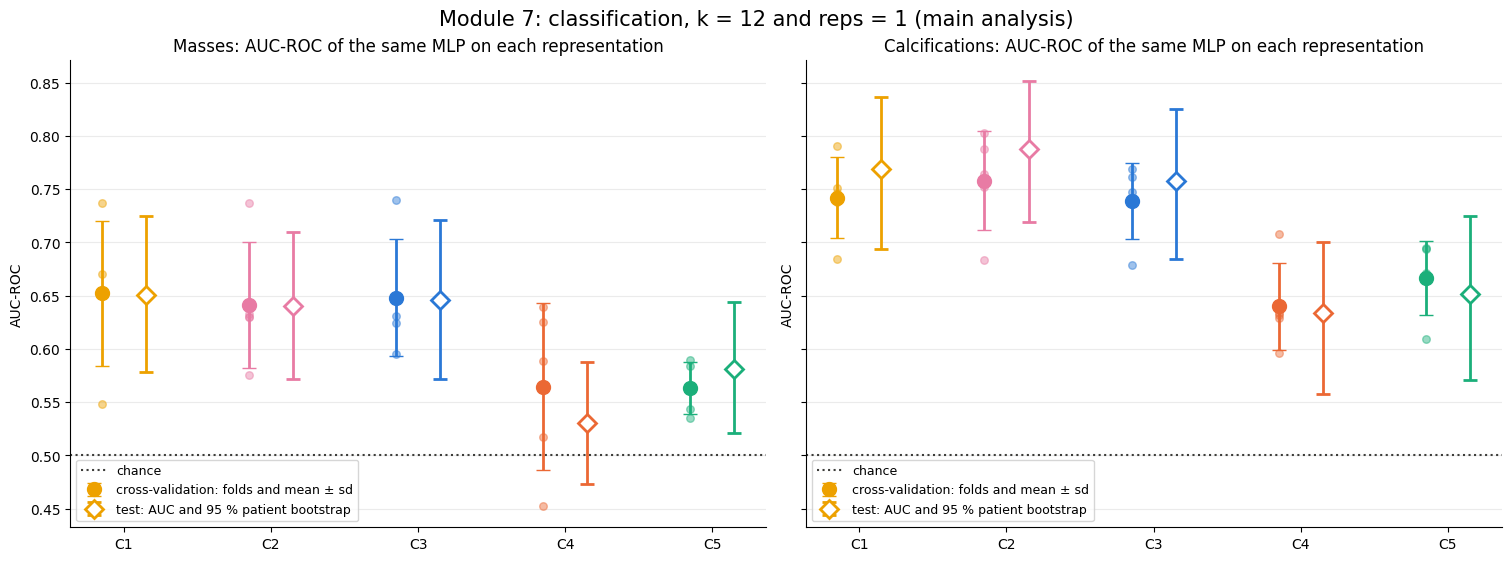

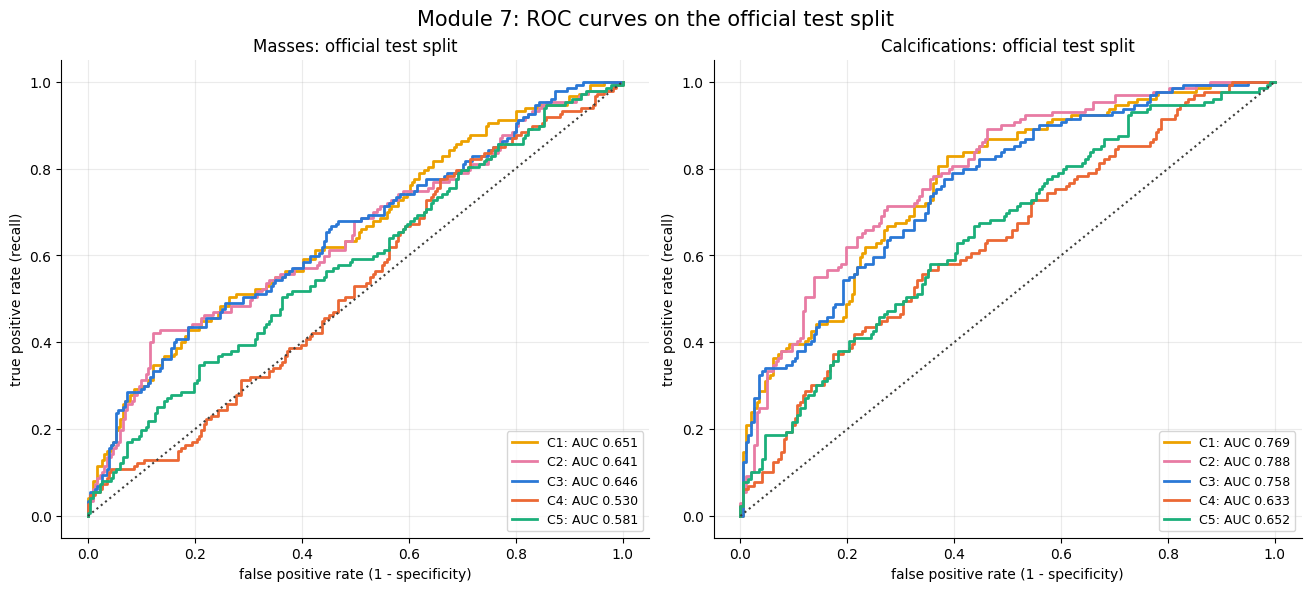

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True, sharey=True)
pos = np.arange(len(CONDITIONS))
for ax, ft in zip(axes, FINDINGS):
    cv = cv_main[cv_main.finding_type == ft]
    te = test_main[test_main.finding_type == ft].set_index('condition').loc[CONDITIONS]
    for i, cond in enumerate(CONDITIONS):
        a = cv[cv.condition == cond].auc
        ax.scatter(np.full(len(a), i - 0.15), a, color=COLORS[cond], alpha=0.45, s=30, zorder=2)
        ax.errorbar(i - 0.15, a.mean(), yerr=a.std(), fmt='o', color=COLORS[cond], markersize=10, capsize=5, zorder=3,
                    label='cross-validation: folds and mean ± sd' if i == 0 else None)
        ax.errorbar(i + 0.15, te.loc[cond, 'auc'], yerr=[[te.loc[cond, 'auc'] - te.loc[cond, 'auc_ci_low']],
                    [te.loc[cond, 'auc_ci_high'] - te.loc[cond, 'auc']]], fmt='D', color=COLORS[cond], markerfacecolor='white',
                    markeredgewidth=2, markersize=9, capsize=5, zorder=3, label='test: AUC and 95 % patient bootstrap' if i == 0 else None)
    ax.axhline(0.5, color=INK, ls=':', lw=1.5, label='chance')
    ax.set_xticks(pos, CONDITIONS)
    ax.grid(axis='x', visible=False)
    ax.set(title=f'{TITLES[ft]}: AUC-ROC of the same MLP on each representation', ylabel='AUC-ROC')
    ax.legend(fontsize=9, loc='lower left')
fig.suptitle('Module 7: classification, k = 12 and reps = 1 (main analysis)', fontsize=15)
fig.savefig(FIG_DIR / 'M7_auc.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), constrained_layout=True)
for ax, ft in zip(axes, FINDINGS):
    te = preds[(preds.finding_type == ft) & (preds.split == 'test') & (preds.analysis == 'main')]
    for cond in CONDITIONS:
        part = te[te.condition == cond]
        fpr, tpr, _ = roc_curve(part.label, part.prob)
        ax.plot(fpr, tpr, color=COLORS[cond], lw=2, label=f'{cond}: AUC {roc_auc_score(part.label, part.prob):.3f}')
    ax.plot([0, 1], [0, 1], color=INK, ls=':', lw=1.5)
    ax.set(xlabel='false positive rate (1 - specificity)', ylabel='true positive rate (recall)', title=f'{TITLES[ft]}: official test split')
    ax.legend(fontsize=9, loc='lower right')
fig.suptitle('Module 7: ROC curves on the official test split', fontsize=15)
fig.savefig(FIG_DIR / 'M7_roc_test.png', dpi=180, bbox_inches='tight')
plt.show()

#### **4° Sensitivity of the training procedure**

**a.** Four more initialization seeds and four alternative configurations, on cross-validation only: a narrower and a wider network, raw inputs without standardization, and 200 epochs without early stopping. The spread across seeds is the size of a difference that the training procedure alone can produce. The configurations show whether the ordering of the conditions depends on the network, on the input scaling or on the stopping rule. The last one answers a natural objection: early stopping halts some quantum fits after a few epochs, and one could suspect that they lose because they are undertrained.

In [9]:
t0 = time.perf_counter()
sens = []
for ft in FINDINGS:
    for seed in EXTRA_SEEDS:
        sens.append(evaluate(frames[ft], 12, CONDITIONS, 'base', seed, 'seeds', test=False)[0].assign(finding_type=ft))
    for name in ['small', 'large', 'raw', 'fixed']:
        sens.append(evaluate(frames[ft], 12, CONDITIONS, name, SEED, f'config {name}', test=False)[0].assign(finding_type=ft))
cv_sens = pd.concat(sens)
print(f'{len(cv_sens)} cross-validation fits in {time.perf_counter() - t0:.0f} s')
seed_table = (pd.concat([cv_main, cv_sens[cv_sens.analysis == 'seeds']])
              .groupby(['finding_type', 'condition', 'seed']).auc.mean().unstack('seed'))
seed_table['range'] = seed_table.max(1) - seed_table.min(1)
display(seed_table.round(3))
config_table = (pd.concat([cv_main.assign(analysis='config base'), cv_sens[cv_sens.analysis.str.startswith('config')]])
                .groupby(['finding_type', 'condition', 'analysis']).auc.mean().unstack('analysis'))
display(config_table.round(3))

400 cross-validation fits in 70 s


seed                        42     43     44     45     46  range
finding_type  condition                                          
calcification C1         0.742  0.747  0.746  0.750  0.752  0.010
              C2         0.758  0.751  0.759  0.779  0.759  0.028
              C3         0.739  0.742  0.752  0.756  0.743  0.017
              C4         0.640  0.640  0.630  0.618  0.626  0.022
              C5         0.667  0.659  0.665  0.652  0.670  0.018
mass          C1         0.652  0.654  0.648  0.646  0.652  0.008
              C2         0.641  0.679  0.658  0.676  0.659  0.038
              C3         0.648  0.665  0.656  0.669  0.645  0.024
              C4         0.565  0.570  0.561  0.545  0.530  0.039
              C5         0.563  0.580  0.551  0.577  0.574  0.029

analysis                 config base  config fixed  config large  config raw  \
finding_type  condition                                                        
calcification C1               0.742         0.754         0.751       0.753   
              C2               0.758         0.753         0.756       0.749   
              C3               0.739         0.736         0.745       0.742   
              C4               0.640         0.596         0.633       0.629   
              C5               0.667         0.631         0.667       0.657   
mass          C1               0.652         0.680         0.674       0.657   
              C2               0.641         0.666         0.685       0.659   
              C3               0.648         0.659         0.656       0.616   
              C4               0.565         0.533         0.562       0.574   
              C5               0.563         0.557         0.580       0.577   

analysis                 config small  
finding_type  condition                
calcification C1                0.743  
              C2                0.747  
              C3                0.743  
              C4                0.635  
              C5                0.667  
mass          C1                0.663  
              C2                0.662  
              C3                0.655  
              C4                0.556  
              C5                0.564

#### **5° Two layers in the ansatz (reps = 2)**

**a.** Recompute C4 and C5 with `real_amplitudes(12, reps=2)` after the same feature maps

H-018 varied the depth of the **ansatz**, with the feature map at one repetition, so that is the variant tested here. The ansatz does not enter the fidelity kernel (D-017), so this changes the embeddings of Module 7 and leaves the kernel metrics of Module 6 untouched. The 36 parameters are drawn with seed 42; the first 24 are the parameters of the one-layer ansatz.

In [10]:
K = 12
ansatz2 = real_amplitudes(K, reps=2)
theta2 = np.random.default_rng(SEED).uniform(0, 2 * np.pi, ansatz2.num_parameters)
theta1 = np.array(json.loads((M5_DIR / 'emb_meta.json').read_text())['theta'])
check('reps = 2: the first 24 parameters equal theta of reps = 1', np.abs(theta2[:24] - theta1).max(), np.array_equal(theta2[:24], theta1))
maps = {'C4': zz_feature_map(K, reps=1), 'C5': pauli_feature_map(K, reps=1, paulis=['Y', 'ZZ'])}
signs = 1.0 - 2.0 * ((np.arange(2 ** K)[:, None] >> np.arange(K)) & 1)


def circuit2(fm, x):
    values = {p: float(v) for p, v in zip(fm.parameters, x)}
    values.update({p: float(v) for p, v in zip(ansatz2.parameters, theta2)})
    return fm.compose(ansatz2).assign_parameters(values, inplace=False)


frames_reps2 = {}
t0 = time.perf_counter()
for ft in FINDINGS:
    base = frames[ft][['case_id', 'patient_id', 'split', 'label', 'fold']].copy()
    x = frames[ft][[f'C1_{j:02d}' for j in range(1, 13)]].to_numpy(float)      # C1 is the angle vector itself
    for q, fm in maps.items():
        z = np.vstack([Statevector.from_instruction(circuit2(fm, row)).probabilities() @ signs for row in x])
        base = base.join(pd.DataFrame(z, index=base.index, columns=cols(q)))
    for i in range(2):
        sv = Statevector.from_instruction(circuit2(maps['C4'], x[i]))
        ref = np.array([sv.expectation_value(SparsePauliOp('I' * (K - 1 - j) + 'Z' + 'I' * j)).real for j in range(K)])
        err = np.abs(ref - base[cols('C4')].to_numpy()[i]).max()
        check(f'{ft}: reps = 2 C4 local Z agrees with SparsePauliOp (lesion {i})', err, err < 1e-12)
    base.to_parquet(OUT_DIR / f'emb_reps2_{ft}.parquet', index=False)
    frames_reps2[ft] = base
    trm = base.split.eq('train').to_numpy()
    one = frames[ft][trm]
    print(f"{ft:13s}: mean per-dimension std on train, reps 1 -> 2: C4 {one[cols('C4')].std().mean():.3f} -> "
          f"{base[trm][cols('C4')].std().mean():.3f}, C5 {one[cols('C5')].std().mean():.3f} -> {base[trm][cols('C5')].std().mean():.3f}")
print(f'reps = 2 embeddings computed in {time.perf_counter() - t0:.0f} s')

mass         : mean per-dimension std on train, reps 1 -> 2: C4 0.058 -> 0.047, C5 0.180 -> 0.196


calcification: mean per-dimension std on train, reps 1 -> 2: C4 0.048 -> 0.043, C5 0.178 -> 0.193
reps = 2 embeddings computed in 59 s


**b.** Cross-validation and test of C4 and C5 with two layers

In [11]:
t0 = time.perf_counter()
for ft in FINDINGS:
    cv, pr = evaluate(frames_reps2[ft], 12, ['C4', 'C5'], 'base', SEED, 'reps2')
    cv_all.append(cv.assign(finding_type=ft))
    pred_all.append(pr.assign(finding_type=ft))
print(f'reps = 2: done in {time.perf_counter() - t0:.0f} s')
cv_reps2 = pd.concat([c for c in cv_all if (c.analysis == 'reps2').all()])
display(pd.concat([cv_main[cv_main.condition.isin(['C4', 'C5'])], cv_reps2])
        .groupby(['finding_type', 'condition', 'analysis']).auc.agg(['mean', 'std']).unstack('analysis').round(3))

reps = 2: done in 3 s


mean           std       
analysis                  main  reps2   main  reps2
finding_type  condition                            
calcification C4         0.640  0.630  0.041  0.031
              C5         0.667  0.698  0.035  0.034
mass          C4         0.565  0.548  0.079  0.052
              C5         0.563  0.614  0.024  0.039

#### **6° Eight qubits (k = 8)**

**a.** The five conditions of experiment X3: the first 8 features of Module 4, with the same circuits on 8 qubits and the same folds

In [12]:
frames_k8 = {}
t0 = time.perf_counter()
for ft in FINDINGS:
    f8 = pd.read_parquet(X3_DIR / f'emb_k8_{ft}.parquet')
    merged = frames[ft][['case_id', 'fold']].merge(f8, on='case_id', suffixes=('_m4', ''))
    check(f'{ft}: k = 8 frame has the same lesions and folds as Module 5', 0,
          len(merged) == len(frames[ft]) and (merged.fold == merged.fold_m4).all())
    frames_k8[ft] = f8
    cv, pr = evaluate(f8, 8, CONDITIONS, 'base', SEED, 'k8')
    cv_all.append(cv.assign(finding_type=ft))
    pred_all.append(pr.assign(finding_type=ft))
print(f'k = 8: done in {time.perf_counter() - t0:.0f} s')
cv_k8 = pd.concat([c for c in cv_all if (c.analysis == 'k8').all()])
display(pd.concat([cv_main, cv_k8]).groupby(['finding_type', 'condition', 'analysis']).auc.agg(['mean', 'std']).unstack('analysis').round(3))

k = 8: done in 9 s


mean           std       
analysis                    k8   main     k8   main
finding_type  condition                            
calcification C1         0.736  0.742  0.031  0.038
              C2         0.767  0.758  0.048  0.046
              C3         0.743  0.739  0.037  0.036
              C4         0.597  0.640  0.033  0.041
              C5         0.657  0.667  0.035  0.035
mass          C1         0.640  0.652  0.062  0.068
              C2         0.616  0.641  0.103  0.059
              C3         0.645  0.648  0.063  0.055
              C4         0.550  0.565  0.026  0.079
              C5         0.563  0.563  0.067  0.024

#### **7° All analyses together**

**a.** Test metrics and paired differences of the sensitivity analyses, and the files of the module

In [13]:
preds = pd.concat(pred_all, ignore_index=True)
test_all, boot = test_table(preds, ['main', 'reps2', 'k8'])
sens_pairs = [(('reps2', q), ('main', q)) for q in ['C4', 'C5']] + \
             [(('k8', c), ('main', c)) for c in CONDITIONS] + \
             [(('k8', q), ('k8', c)) for q in ['C4', 'C5'] for c in ['C1', 'C3']] + \
             [(('reps2', q), ('main', c)) for q in ['C4', 'C5'] for c in ['C1', 'C3']]
diff_all = pd.concat([differences(boot, main_pairs, 'main'), differences(boot, sens_pairs, 'sensitivity')], ignore_index=True)
cv_every = pd.concat(cv_all + [cv_sens], ignore_index=True)
cv_summary = (cv_every.groupby(['finding_type', 'analysis', 'k', 'config', 'seed', 'condition'])
              [['auc', 'f1', 'accuracy', 'precision', 'recall', 'epochs']].agg(['mean', 'std']))
cv_summary.columns = [f'{m}_{s}' for m, s in cv_summary.columns]
cv_every.to_csv(RESULTS_DIR / '7_cv_por_fold.csv', index=False)
cv_summary.reset_index().to_csv(RESULTS_DIR / '7_cv_resumen.csv', index=False)
test_all.to_csv(RESULTS_DIR / '7_test.csv', index=False)
diff_all.to_csv(RESULTS_DIR / '7_test_diferencias.csv', index=False)
preds.to_parquet(OUT_DIR / 'predicciones.parquet', index=False)
display(test_all.pivot_table(index=['finding_type', 'condition'], columns='analysis', values='auc')[['main', 'reps2', 'k8']].round(3))
display(diff_all[diff_all.group == 'sensitivity'].round(3))

analysis                  main  reps2     k8
finding_type  condition                     
calcification C1         0.769    NaN  0.752
              C2         0.788    NaN  0.797
              C3         0.758    NaN  0.765
              C4         0.633  0.657  0.561
              C5         0.652  0.682  0.640
mass          C1         0.651    NaN  0.634
              C2         0.641    NaN  0.650
              C3         0.646    NaN  0.636
              C4         0.530  0.536  0.556
              C5         0.581  0.603  0.561

,finding_type,comparison,group,mean_difference,ci_low,ci_high,share_above_0
14,mass,C4 (reps2) - C4 (main),sensitivity,0.005,-0.064,0.073,0.563
15,mass,C5 (reps2) - C5 (main),sensitivity,0.022,-0.046,0.089,0.741
16,mass,C1 (k8) - C1 (main),sensitivity,-0.017,-0.047,0.012,0.118
17,mass,C2 (k8) - C2 (main),sensitivity,0.009,-0.034,0.051,0.650
18,mass,C3 (k8) - C3 (main),sensitivity,-0.010,-0.054,0.038,0.333
19,mass,C4 (k8) - C4 (main),sensitivity,0.025,-0.049,0.093,0.754
20,mass,C5 (k8) - C5 (main),sensitivity,-0.019,-0.084,0.047,0.289
21,mass,C4 (k8) - C1 (k8),sensitivity,-0.080,-0.157,-0.003,0.021
22,mass,C4 (k8) - C3 (k8),sensitivity,-0.081,-0.156,-0.002,0.022
23,mass,C5 (k8) - C1 (k8),sensitivity,-0.072,-0.130,-0.011,0.012


**b.** Figure: cross-validated AUC of every analysis. Each condition keeps its color; the marker shape identifies the analysis. The vertical bar on the main marker is the range over the five seeds.

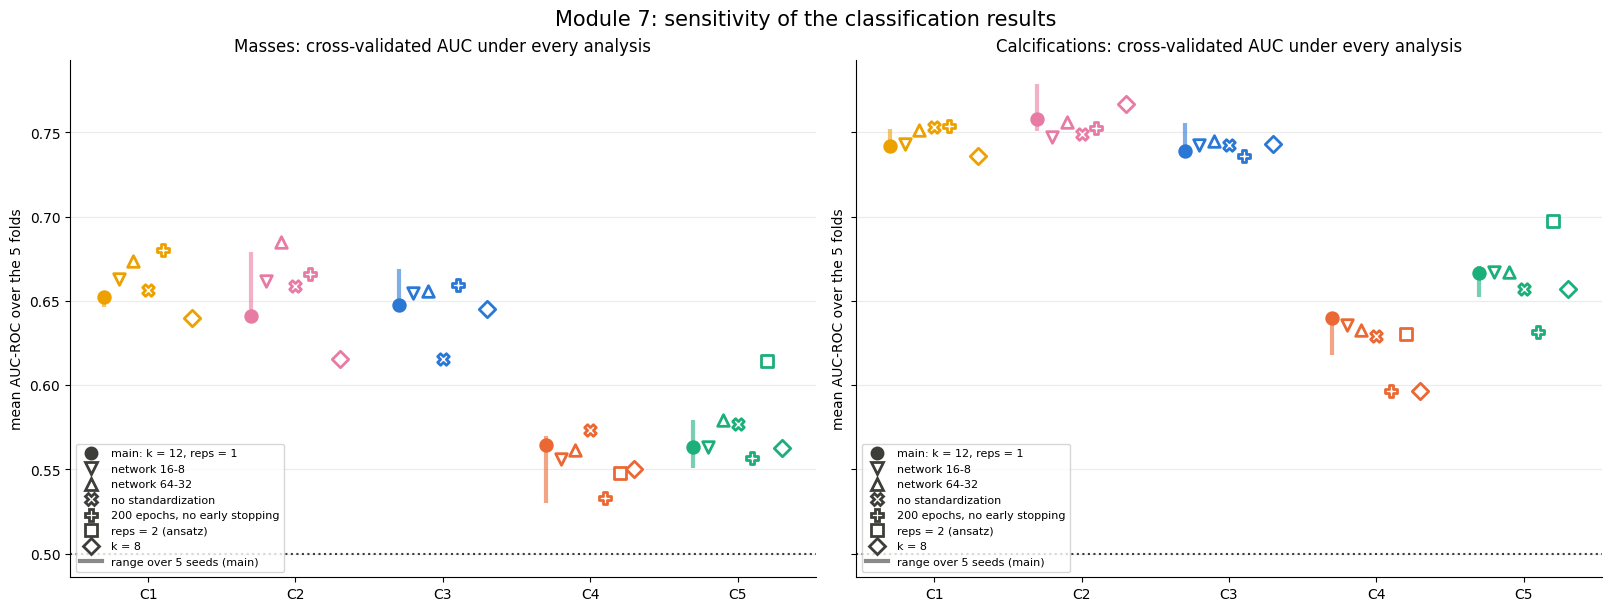

In [14]:
variants = [('main', 'o', 'main: k = 12, reps = 1'), ('config small', 'v', 'network 16-8'), ('config large', '^', 'network 64-32'),
            ('config raw', 'X', 'no standardization'), ('config fixed', 'P', '200 epochs, no early stopping'),
            ('reps2', 's', 'reps = 2 (ansatz)'), ('k8', 'D', 'k = 8')]
means = cv_every[cv_every.seed.eq(SEED) | cv_every.analysis.eq('seeds')].groupby(['finding_type', 'analysis', 'seed', 'condition']).auc.mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True, sharey=True)
offsets = np.linspace(-0.3, 0.3, len(variants))
for ax, ft in zip(axes, FINDINGS):
    for (analysis, marker, label), off in zip(variants, offsets):
        for i, cond in enumerate(CONDITIONS):
            key = (ft, analysis, SEED, cond)
            if key not in means.index:
                continue
            face = COLORS[cond] if analysis == 'main' else 'white'
            ax.scatter(i + off, means[key], marker=marker, s=70, facecolor=face, edgecolor=COLORS[cond], linewidth=2, zorder=3)
            if analysis == 'main':
                seeds = [means[(ft, 'main', SEED, cond)]] + [means[(ft, 'seeds', s, cond)] for s in EXTRA_SEEDS]
                ax.vlines(i + off, min(seeds), max(seeds), color=COLORS[cond], lw=3, alpha=0.6, zorder=2)
    ax.axhline(0.5, color=INK, ls=':', lw=1.5)
    ax.set_xticks(np.arange(len(CONDITIONS)), CONDITIONS)
    ax.grid(axis='x', visible=False)
    ax.set(title=f'{TITLES[ft]}: cross-validated AUC under every analysis', ylabel='mean AUC-ROC over the 5 folds')
    handles = [Line2D([], [], marker=m, linestyle='', markersize=8, markeredgewidth=2, markeredgecolor=INK,
                      markerfacecolor=INK if a == 'main' else 'white', label=l) for a, m, l in variants]
    handles.append(Line2D([], [], color=INK, lw=3, alpha=0.6, label='range over 5 seeds (main)'))
    ax.legend(handles=handles, fontsize=8, loc='lower left')
fig.suptitle('Module 7: sensitivity of the classification results', fontsize=15)
fig.savefig(FIG_DIR / 'M7_sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()

#### **8° Verifications**

In [15]:
cv_main_now = cv_every[cv_every.analysis == 'main']
check('every main fit stopped before the epoch limit', cv_main_now.epochs.max(), cv_main_now.epochs.max() < MAX_EPOCHS)
check('every test prediction is a probability', 0, preds.prob.between(0, 1).all())
n_expected = 2 * (5 + 2 + 5)
check('one test model per subset, analysis and condition', preds[preds.split == 'test'].groupby(['finding_type', 'analysis', 'condition']).ngroups,
      preds[preds.split == 'test'].groupby(['finding_type', 'analysis', 'condition']).ngroups == n_expected)
verifications = pd.DataFrame(checks)
verifications.to_csv(RESULTS_DIR / '7_verificaciones.csv', index=False)
display(verifications)
print(f'Checks passed: {int(verifications.passed.sum())}/{len(verifications)}')

,check,value,passed
0,mass: no patient has lesions in two folds,0.000000e+00,True
1,mass: train lesions have folds 0-4 and test le...,0.000000e+00,True
2,calcification: no patient has lesions in two f...,0.000000e+00,True
3,calcification: train lesions have folds 0-4 an...,0.000000e+00,True
4,class weights: w_c = N / (2 N_c) and the weigh...,0.000000e+00,True
5,refitting with the same seed reproduces the pr...,0.000000e+00,True
6,reps = 2: the first 24 parameters equal theta ...,0.000000e+00,True
7,mass: reps = 2 C4 local Z agrees with SparsePa...,6.544244e-16,True
8,mass: reps = 2 C4 local Z agrees with SparsePa...,3.712308e-16,True
9,calcification: reps = 2 C4 local Z agrees with...,1.838807e-16,True


Checks passed: 16/16


#### **9° Consequence**

**1. The quantum representations classify worse than the classical ones, in both subsets and on both evaluations.**

| AUC-ROC | C1 | C2 | C3 | C4 | C5 |
|---|---|---|---|---|---|
| Masses, cross-validation | 0.652 | 0.641 | 0.648 | 0.565 | 0.563 |
| Masses, test [95 % patient bootstrap] | 0.651 [0.58, 0.72] | 0.641 | 0.646 | 0.530 [0.47, 0.59] | 0.581 [0.52, 0.64] |
| Calcifications, cross-validation | 0.742 | 0.758 | 0.739 | 0.640 | 0.667 |
| Calcifications, test | 0.769 [0.69, 0.84] | 0.788 | 0.758 | 0.633 [0.56, 0.70] | 0.652 [0.57, 0.73] |

On the test split the paired differences against C1 are:

- **Masses:** −0.12 for C4 [−0.20, −0.04] and −0.07 for C5 [−0.14, −0.004].
- **Calcifications:** −0.14 for C4 [−0.21, −0.06] and −0.12 for C5 [−0.18, −0.05].

Against C3 the picture is the same, except C5 in masses, whose interval just touches zero (−0.065 [−0.14, 0.002]). C4 in masses cannot be told apart from chance on the test split.

**Two checks support these numbers.**

- **The null control (D-016).** C2 against C1 differs by −0.011 [−0.06, 0.04] in masses and +0.020 [−0.03, 0.07] in calcifications. A rotation does not change the information, and the training procedure does not invent a difference where there is none.
- **A classical reference.** The MLP on C1 matches the logistic regression of X1 on the same 12 features (0.650 and 0.758 in cross-validation, H-035): the network extracts what a linear model extracts, no less.

**2. The result does not come from the training procedure.**

- Across five initialization seeds, the cross-validated AUC of a condition moves by at most 0.039. That is less than half of the gap between the classical and the quantum conditions, which is about 0.08–0.10.
- A narrower network, a wider one and raw inputs without standardization leave the ordering unchanged.
- **Training longer does not help the quantum conditions.** With 200 epochs and no early stopping, C4 and C5 lose AUC (in masses 0.533 and 0.557; in calcifications 0.596 and 0.631), while the classical conditions keep or gain it (C1 in masses: 0.680). The quantum fits that stop after a few epochs stop because their validation loss stops improving, not because they are undertrained.

**3. Two layers in the ansatz (reps = 2) help C5 a little and do not close the gap.**

- **Dispersion on real data.** C4 becomes slightly less dispersed (0.058 → 0.047 in masses) and C5 slightly more (0.180 → 0.196). The 30 % increase that H-018 measured on synthetic inputs, averaged over draws of θ, does not reproduce for C4 with the θ of this design.
- **Classification.** C5 gains in cross-validation (masses 0.563 → 0.614, calcifications 0.667 → 0.698) and on test (0.581 → 0.603 and 0.652 → 0.682). The paired test differences contain zero ([−0.05, 0.09] and [−0.04, 0.10]). C4 does not change.
- **Against C1, C5 with two layers is still below on test:** −0.048 [−0.093, −0.005] in masses and −0.086 [−0.141, −0.034] in calcifications.

**4. Eight qubits do not help either.**

- The classical conditions barely change: C1 goes from 0.652 to 0.640 in masses and from 0.742 to 0.736 in calcifications.
- C4 drops in calcifications: 0.597 in cross-validation and 0.561 on test, a difference of −0.07 [−0.14, 0.00] from $k=12$. C5 stays where it was.
- The quantum conditions stay below C1 on test in both subsets, by 0.07 to 0.19.

At $k=8$ the kernel metrics of C4 improved (X3, H-041) while its classification got worse. This is another case of H-013: the kernel and the $\langle Z_i\rangle$ embedding are different objects, and a more dispersed embedding is not necessarily more informative.

**5. What this answers (OE-4 and OE-5).** The same classifier performs worse on the quantum representations than on the classical ones. The answer is consistent with the separability of Module 6 and robust to seeds, network, input scaling, stopping rule, depth of the ansatz and number of qubits. C5 is ahead of C4 in almost every analysis, but never by a significant margin. The exceptions are two cross-validation runs in masses, with seeds 42 and 44. The Y term (D-031) helps the embedding without making it competitive.

**Limits.**

- The bootstrap intervals are not adjusted for the number of comparisons.
- The hyperparameters were fixed a priori and not tuned. The sensitivity analyses show that the conclusion does not depend on them, but they do not exhaust every possible classifier.
- The correlation between the rankings of separability and classification (RF-21) belongs to Module 8.


In [16]:
print('=' * 92)
print('MODULE 7 - CLASSIFICATION - SUMMARY (AUC-ROC; CV = mean over 5 folds; test with 95 % patient bootstrap)')
print('=' * 92)
for ft in FINDINGS:
    print(f'  {TITLES[ft]}')
    for analysis, conds in [('main', CONDITIONS), ('reps2', ['C4', 'C5']), ('k8', CONDITIONS)]:
        cv = cv_every[(cv_every.finding_type == ft) & (cv_every.analysis == analysis)].groupby('condition').auc.mean()
        te = test_all[(test_all.finding_type == ft) & (test_all.analysis == analysis)].set_index('condition')
        print(f'    {analysis:6s} CV   ' + ' | '.join(f'{c} {cv[c]:.3f}' for c in conds))
        print(f'    {"":6s} test ' + ' | '.join(f"{c} {te.loc[c, 'auc']:.3f} [{te.loc[c, 'auc_ci_low']:.2f}, {te.loc[c, 'auc_ci_high']:.2f}]" for c in conds))
print(f"  Checks passed: {int(verifications.passed.sum())}/{len(verifications)}")
print('=' * 92)

MODULE 7 - CLASSIFICATION - SUMMARY (AUC-ROC; CV = mean over 5 folds; test with 95 % patient bootstrap)
  Masses
    main   CV   C1 0.652 | C2 0.641 | C3 0.648 | C4 0.565 | C5 0.563
           test C1 0.651 [0.58, 0.72] | C2 0.641 [0.57, 0.71] | C3 0.646 [0.57, 0.72] | C4 0.530 [0.47, 0.59] | C5 0.581 [0.52, 0.64]
    reps2  CV   C4 0.548 | C5 0.614
           test C4 0.536 [0.47, 0.60] | C5 0.603 [0.53, 0.68]
    k8     CV   C1 0.640 | C2 0.616 | C3 0.645 | C4 0.550 | C5 0.563
           test C1 0.634 [0.56, 0.71] | C2 0.650 [0.58, 0.72] | C3 0.636 [0.56, 0.71] | C4 0.556 [0.49, 0.62] | C5 0.561 [0.49, 0.63]
  Calcifications
    main   CV   C1 0.742 | C2 0.758 | C3 0.739 | C4 0.640 | C5 0.667
           test C1 0.769 [0.69, 0.84] | C2 0.788 [0.72, 0.85] | C3 0.758 [0.68, 0.83] | C4 0.633 [0.56, 0.70] | C5 0.652 [0.57, 0.73]
    reps2  CV   C4 0.630 | C5 0.698
           test C4 0.657 [0.59, 0.72] | C5 0.682 [0.61, 0.75]
    k8     CV   C1 0.736 | C2 0.767 | C3 0.743 | C4 0.597 | C5 0.